# 均值-方差投资组合 · 七幕总览 Notebook

> 一个文件读完整个项目：从样本内闭式解，到样本外翻车，到修 Σ / 修 μ / 维数边界 / 理论最优，再到真实数据验证。
> 每段都现场调用 `src/` 模块算出关键数字——**所有输出都是真实运行结果**。

完整叙事见 [README](README.md) ｜ [English](README_EN.md) ｜ 数学推导 [docs/derivation.pdf](docs/derivation.pdf)

---
本 Notebook 复用仓库已生成的图（`figures/*.png`），并现算核心指标做交叉印证。

In [1]:
import sys, os, json
sys.path.insert(0, "src")
import numpy as np
import data_utils as du, analytic as an, generate_data as gen
import backtest as bt, bootstrap as bs, metrics as mt
from IPython.display import Image, Markdown, display

RF = 0.03
R = du.load_returns("data/returns_long.csv").to_numpy()   # 合成 10 年序列
mu_true = gen.true_mu_annual()
print(f"合成数据: {R.shape[0]} 个交易日 × {R.shape[1]} 只资产")
print(f"真实年化 μ (%): {np.round(mu_true*100,1)}")

合成数据: 2520 个交易日 × 8 只资产
真实年化 μ (%): [18. 15. 12.  8.  6. 10.  7.  5.]


## 第一幕 · 样本内：闭式解（Cholesky）

解析法用手写 Cholesky 前代/回代求解对称正定系统，得到 GMV 与切点组合。这是矩阵算法的基石。

GMV   : 收益  6.66%  波动 15.84%
切点  : 收益 18.50%  波动 32.62%  夏普 0.475


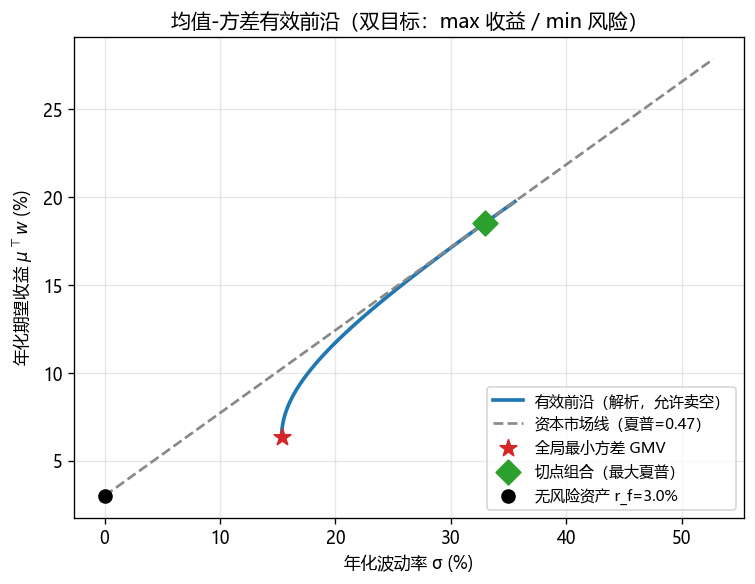

In [2]:
mu = du.annualize_mu(du.estimate_mu(R))
Sigma = du.annualize_cov(du.ledoit_wolf_shrinkage(R)[0])
gmv = an.gmv_portfolio(mu, Sigma)
tan = an.tangency_portfolio(mu, Sigma, RF)
print(f"GMV   : 收益 {gmv['ret']*100:5.2f}%  波动 {gmv['vol']*100:5.2f}%")
print(f"切点  : 收益 {tan['ret']*100:5.2f}%  波动 {tan['vol']*100:5.2f}%  夏普 {tan['sharpe']:.3f}")
display(Image("figures/efficient_frontier.png"))

## 第二幕 · 样本外：估计误差摧毁"最优"

严格无前视的滚动回测。样本内夏普最高的切点组合，样本外夏普塌成负数；朴素等权 1/N 反而最稳。

等权 1/N           样本外夏普  0.450  年化波动    18.4%  换手     0.0%
切点（样本μ,Σ）        样本外夏普 -0.165  年化波动  1009.2%  换手  2429.1%
Oracle切点（真μ）     样本外夏普  0.490  年化波动    32.5%  换手    12.5%


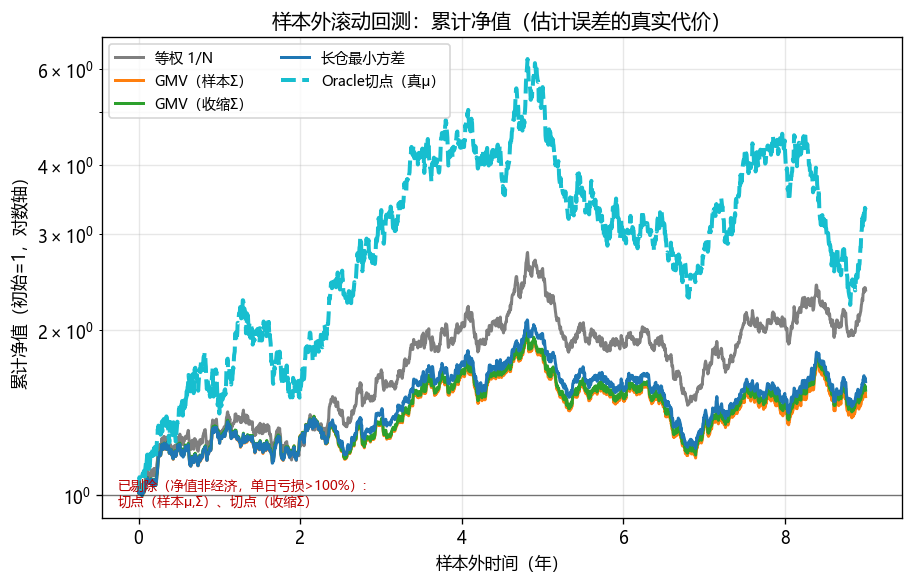

In [3]:
res = bt.run_backtest(R, mu_true, L=252, R=21, rf_annual=RF)
for s in ["等权 1/N", "切点（样本μ,Σ）", "Oracle切点（真μ）"]:
    st = mt.annualized_stats(res["daily_oos"][s], RF)
    to = mt.turnover(res["weights_hist"][s])
    print(f"{s:<16} 样本外夏普 {st['sharpe']:>6.3f}  年化波动 {st['ann_vol']*100:>7.1f}%  换手 {to*100:>7.1f}%")
display(Image("figures/backtest_wealth.png"))

**结论**：切点（样本μ）样本外失控——波动/换手爆炸；等权 1/N 胜出；Oracle（真μ）最优 → 元凶是 **μ 的估计误差**。

## 第三幕 · 修 Σ + 显著性检验

四种协方差估计同台，并用 block bootstrap 给夏普加置信区间。

等权 1/N         夏普  0.450  95%CI [-0.234, 1.151]  p(vs 1/N)=1.000
GMV（样本Σ）       夏普  0.180  95%CI [-0.462, 0.810]  p(vs 1/N)=0.125
GMV（收缩Σ）       夏普  0.199  95%CI [-0.449, 0.839]  p(vs 1/N)=0.144
GMV（NLS）       夏普  0.203  95%CI [-0.443, 0.840]  p(vs 1/N)=0.177


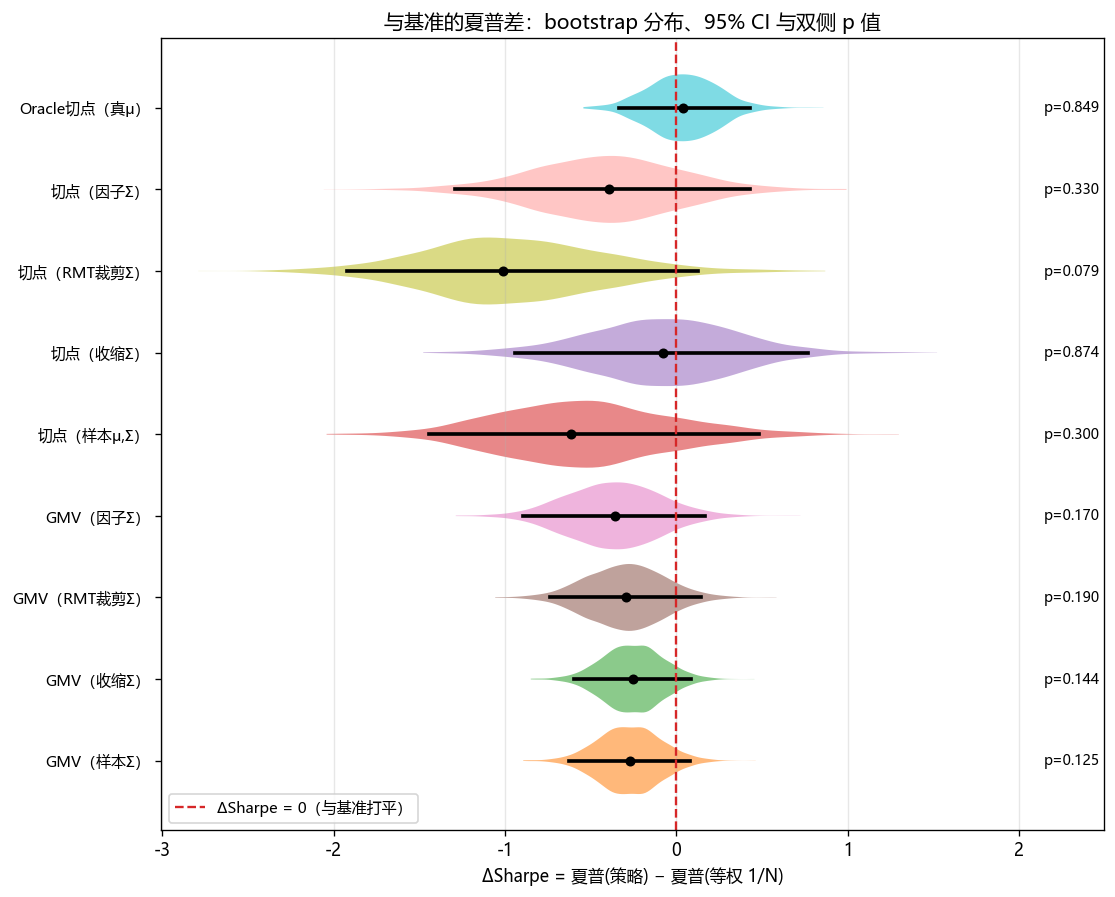

In [4]:
extra = {"rmt": lambda w: du.mp_clipped_covariance(w)[0],
         "nls": lambda w: du.nls_covariance(w)[0]}
strat = {"等权 1/N": bt.STRATEGIES["等权 1/N"],
         "GMV（样本Σ）": bt.STRATEGIES["GMV（样本Σ）"],
         "GMV（收缩Σ）": bt.STRATEGIES["GMV（收缩Σ）"],
         "GMV（NLS）": bt.make_strategy("gmv","Sigma_nls")}
r3 = bt.run_backtest(R, mu_true, rf_annual=RF, strategies=strat, extra_covs=extra)
labels = list(r3["daily_oos"].keys())
dm = np.column_stack([r3["daily_oos"][s] for s in labels])
boot = bs.joint_sharpe_bootstrap(dm, labels, RF, "等权 1/N", B=2000, seed=2024)
for i,s in enumerate(labels):
    ci = boot["sharpe_ci"][i]; p = boot["delta_vs_benchmark"][s]["p_value"]
    print(f"{s:<14} 夏普 {boot['sharpe_point'][i]:>6.3f}  95%CI [{ci[0]:>6.3f},{ci[1]:>6.3f}]  p(vs 1/N)={p:.3f}")
display(Image("figures/covariance_delta_sharpe.png"))

**结论**：GMV 各版本差距小（修 Σ 救不了 μ），且**没有策略与 1/N 的差距显著**（CI 全部横跨 0）。

## 第四幕 · 修 μ：Bayes-Stein 与 Black-Litterman

既然元凶是 μ，就对 μ 收缩。并验证"无观点 BL = 持有市场"定理。

μ 估计误差(年化): 样本 0.449 → JS 0.338 → 均衡π 0.324
BL 无观点切点 vs 等权 1/N: max|w − 1/n| = 1.67e-16  (≡ 持有市场)


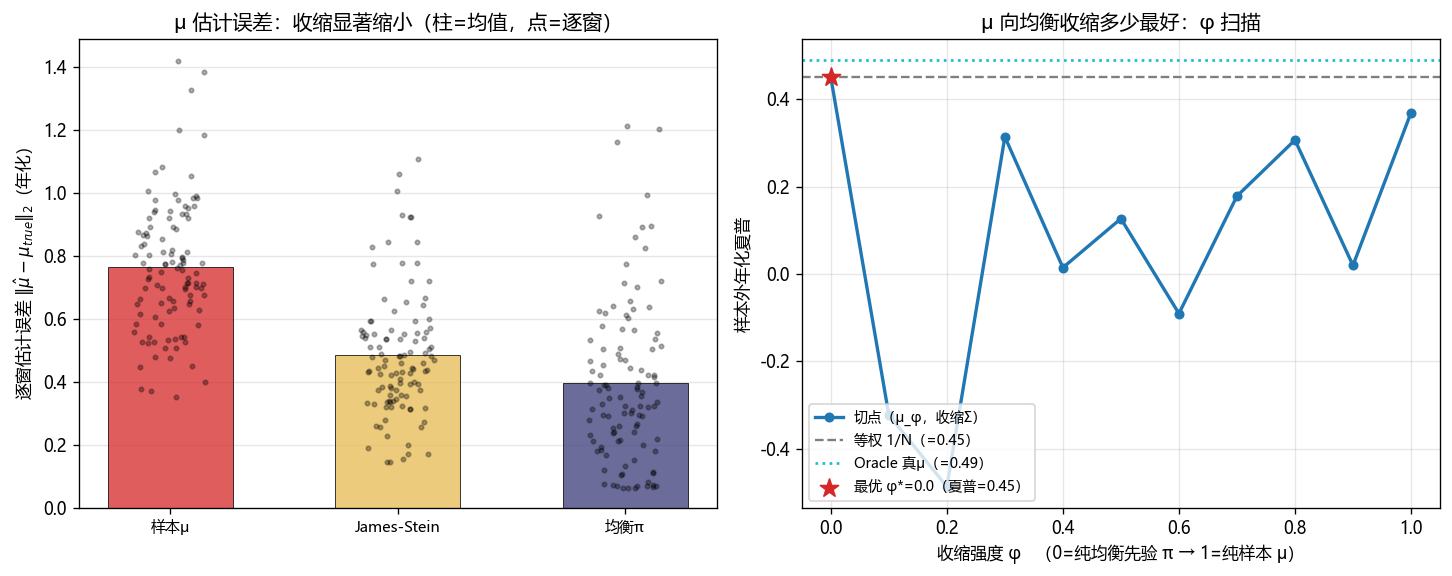

In [5]:
win = R[:252]
mu_hat = win.mean(axis=0); mu_js,_ = du.js_shrunk_mu(win); pi,_ = du.equilibrium_mu(win, RF/252)
mt_=mu_true/252
print(f"μ 估计误差(年化): 样本 {np.linalg.norm(mu_hat-mt_)*252:.3f} → JS {np.linalg.norm(mu_js-mt_)*252:.3f} → 均衡π {np.linalg.norm(pi-mt_)*252:.3f}")
# BL 定理：无观点均衡切点 ≡ 等权
w_bl = an.tangency_portfolio(du.annualize_mu(pi), du.annualize_cov(du.ledoit_wolf_shrinkage(win)[0]), RF)["weights"]
print(f"BL 无观点切点 vs 等权 1/N: max|w − 1/n| = {np.max(np.abs(w_bl - 1/R.shape[1])):.2e}  (≡ 持有市场)")
display(Image("figures/mu_diagnosis.png"))

**结论**：JS 收缩把 μ 误差砍掉约 36%、换手减半（方向对，仍难赢 1/N）；BL 无观点切点精确还原等权（机器精度）。

## 第五幕 · 维数相变：给 RMT 翻案

固定 T=252，把资产数扫到 200。样本协方差在高维崩溃，RMT/因子/NLS 维数免疫。

n=8    q=0.03  GMV波动: 样本Σ 18.24%  NLS 18.22%  条件数中位 样本=9


n=50   q=0.20  GMV波动: 样本Σ 13.98%  NLS 13.48%  条件数中位 样本=131


n=200  q=0.79  GMV波动: 样本Σ 17.47%  NLS  9.39%  条件数中位 样本=10994


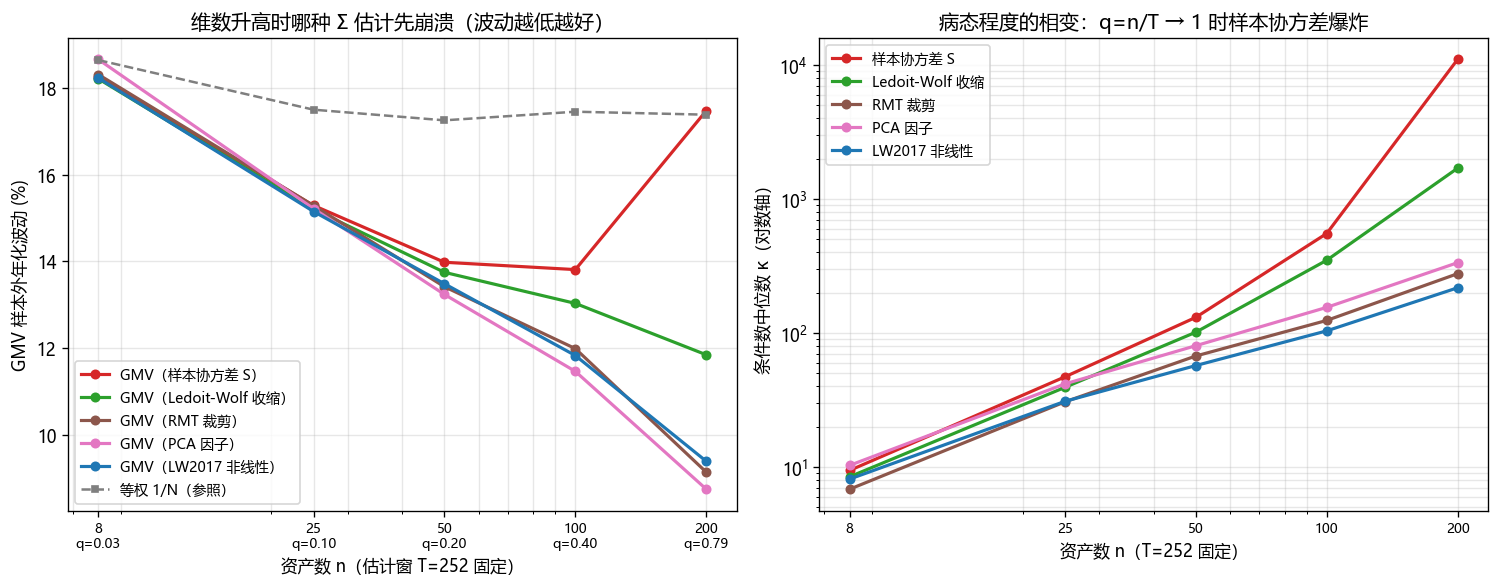

In [6]:
for n in [8, 50, 200]:
    dfu, alpha = gen.generate_universe(n, n_days=2520, seed=7)
    rr = bt.run_backtest(dfu.to_numpy(), alpha, rf_annual=RF,
            strategies={"GMV（样本Σ）": bt.STRATEGIES["GMV（样本Σ）"],
                        "GMV（NLS）": bt.make_strategy("gmv","Sigma_nls")},
            extra_covs={"nls": lambda w: du.nls_covariance(w)[0]})
    vs = mt.annualized_stats(rr["daily_oos"]["GMV（样本Σ）"], RF)["ann_vol"]
    vn = mt.annualized_stats(rr["daily_oos"]["GMV（NLS）"], RF)["ann_vol"]
    print(f"n={n:<4} q={n/252:.2f}  GMV波动: 样本Σ {vs*100:5.2f}%  NLS {vn*100:5.2f}%  条件数中位 样本={np.median(rr['cond_sample']):.0f}")
display(Image("figures/nls_dimension_phase.png"))

**结论**：n=200 时样本协方差 GMV 崩回 ~17%（和等权一样差，条件数破万），NLS 一路降到 ~9%。RMT 低维误伤、高维救命。

## 第六幕 · 理论最优 Σ：非线性收缩

一张"收缩函数图"看尽所有方法对特征值的改造：样本=单位线、线性=斜线、RMT=台阶、NLS=最优曲线。

条件数: 样本 11.1 → NLS 9.5
高维 n=100: 条件数 样本 580 → NLS 117


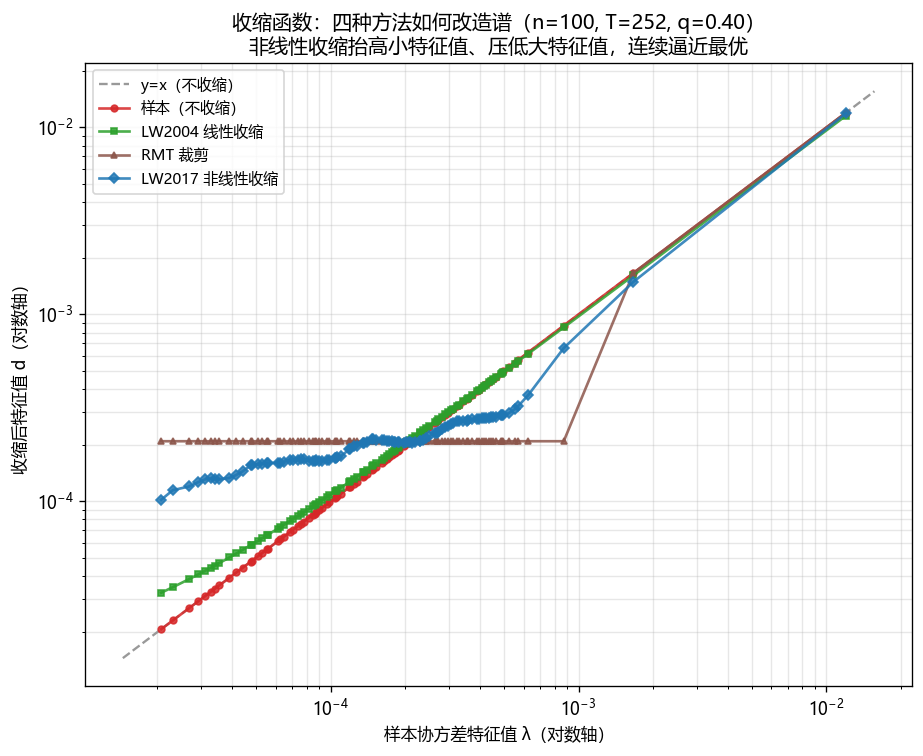

In [7]:
S = du.sample_covariance(win); Snls,_ = du.nls_covariance(win)
print(f"条件数: 样本 {du.condition_number(S):.1f} → NLS {du.condition_number(Snls):.1f}")
dfu,_ = gen.generate_universe(100, n_days=2520, seed=7); w100 = dfu.to_numpy()[:252]
print(f"高维 n=100: 条件数 样本 {du.condition_number(du.sample_covariance(w100)):.0f} → NLS {du.condition_number(du.nls_covariance(w100)[0]):.0f}")
display(Image("figures/nls_shrinkage_functions.png"))

## 尾声 · 真实数据验证

把同一套协议搬到 8 只真实行业 ETF（2012–2023）。结论复制率 89%。

复制率（相对 1/N 方向一致）: 89%
等权 1/N             真实夏普  0.622  Δvs1N  0.000 (p=1.00)
切点（样本μ,Σ）          真实夏普 -0.011  Δvs1N -0.633 (p=0.08)
事后切点（全样本μ）         真实夏普  0.983  Δvs1N  0.360 (p=0.18)


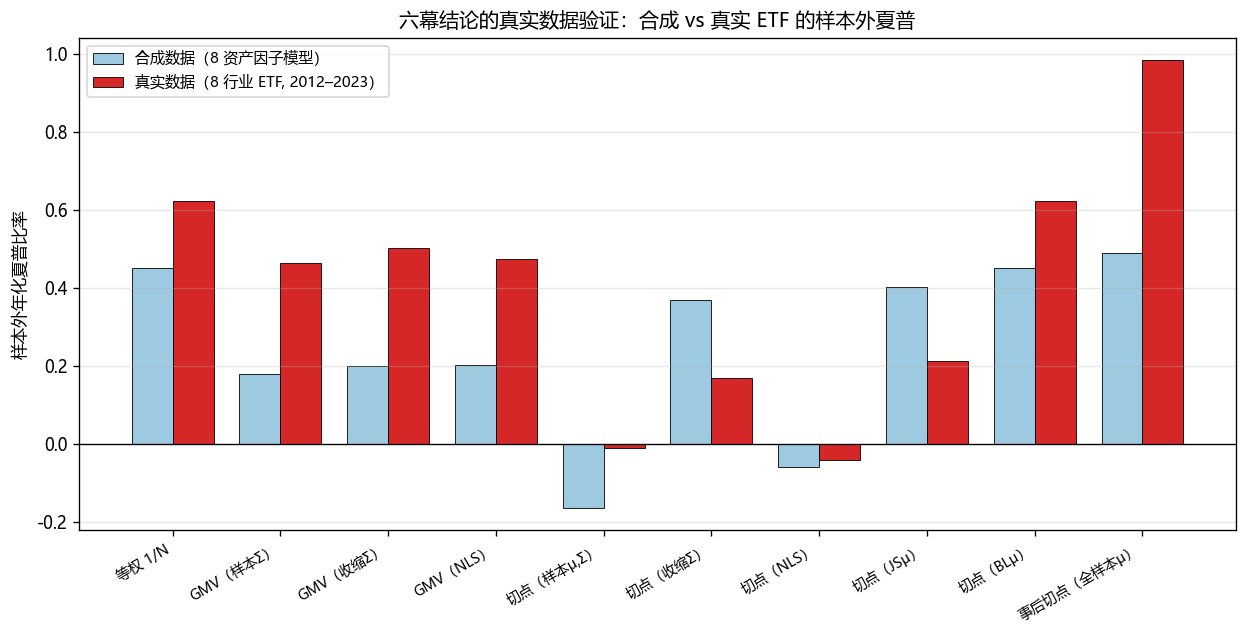

In [8]:
real = json.load(open("results/real_summary.json", encoding="utf-8"))
print(f"复制率（相对 1/N 方向一致）: {real['replication_rate_vs_1N_sign']*100:.0f}%")
for s in ["等权 1/N","切点（样本μ,Σ）","事后切点（全样本μ）"]:
    d = real["real"][s]
    print(f"{s:<18} 真实夏普 {d['oos_sharpe']:>6.3f}  Δvs1N {d['delta_vs_1N']:>6.3f} (p={d['p_value']:.2f})")
display(Image("figures/real_vs_synth.png"))

**结论**：1/N 真实数据仍称王（0.62）；切点样本μ 爆得更惨（换手3370%、回撤-3206%）；唯一胜出的事后μ（作弊）仍不显著（p=0.18）。
**六幕结论源于均值-方差问题的结构本身，而非合成数据特例。**

---

## 一句话总结

> 风险（Σ）能估好、越高维越该用非线性收缩；收益（μ）几乎估不好，所以纯优化的"最优"组合样本外往往输给朴素的等权 1/N——而且这个差距常常连统计显著性都达不到。